# Dynamic Low-Volatility Selection

**Enhancement over `top50mcap_analysis.ipynb`** — adaptive stock count with inverse-vol weighting.

## Strategy

Each month, stocks are selected using a single clean rule:

| Step | Logic |
|---|---|
| **1. Percentile filter** | Select stocks where `Vol_Regime_Smooth ≤ SIGNAL_CUTOFF_PCT` cross-sectionally |
| **2. Absolute filter** | Also require `Vol_Regime_Smooth ≤ SIGNAL_CUTOFF_ABS` (no "calmest in a storm" picks) |
| **3. Ceiling** | Cap at `MAX_STOCKS = 10` — take the best N if more than 10 pass |
| **4. No floor** | If only 3 (or 1) stocks pass, hold 3 (or 1) — this is **intentional de-risking** |
| **5. InvVol weights** | `w_i = (1/signal_i) / Σ(1/signal_j)` — calmest stocks get more weight |

**Why no floor?**
The floor was the single biggest source of underperformance in earlier versions.
It forced inclusion of lower-quality stocks precisely during stressed regimes — the opposite of what a low-vol strategy should do.
Holding fewer stocks (or even 1–2) during high-vol regimes IS the strategy working correctly.

**Why InvVol weights?**
Backtested in `top50mcap_analysis.ipynb` — added +2.25pp CAGR and +0.10 Sharpe over equal-weight
on the same stock selection with zero additional complexity.

> **Inputs required:**
> - `ticker_signals_cache.xlsx` — signal history per ticker
> - `mcap_based_universe_202602251340.csv` — market cap universe history
>
> **Output:** `dynamic_low_vol_selection.xlsx`

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from pathlib import Path

# ── Paths ─────────────────────────────────────────────────────────────────────
BASE_DIR           = Path(r'D:\Linear Model')
SIGNAL_CACHE_FILE  = BASE_DIR / 'ticker_signals_cache.xlsx'
MCAP_CSV           = BASE_DIR / 'mcap_based_universe_202602251340.csv'
OUTPUT_FILE        = BASE_DIR / 'dynamic_low_vol_selection.xlsx'
TRADING_DAYS_EXCEL = r'D:\Linear Model\data\Universe\TradingDays.xlsx'

# ── Date range ────────────────────────────────────────────────────────────────
SIGNAL_START   = pd.Timestamp('2020-01-01')

# ── Universe ──────────────────────────────────────────────────────────────────
TOP_N_UNIVERSE = 50

# ── Selection parameters ──────────────────────────────────────────────────────
# Cross-sectional percentile threshold.
# 20th pct from 50 stocks = bottom 10 stocks on average → matches original top-10.
# Stocks in the bottom SIGNAL_CUTOFF_PCT% of the cross-section this month pass.
SIGNAL_CUTOFF_PCT = 20       # percentile (0-100); ~10 stocks from 50 on average

# Absolute signal threshold on the 0-1 calibrated scale.
# Stocks must ALSO be ≤ this value to pass (prevents "calmest in a storm" picks).
SIGNAL_CUTOFF_ABS = 0.45

# Hard ceiling — never hold more than this many stocks.
# No floor: if 2 stocks pass, hold 2. That IS the strategy working correctly.
MAX_STOCKS = 10

print('Configuration loaded.')
print(f'  Signal used           : Vol_Regime_Smooth only')
print(f'  Percentile threshold  : bottom {SIGNAL_CUTOFF_PCT}th pct  '
      f'(~{int(TOP_N_UNIVERSE * SIGNAL_CUTOFF_PCT / 100)} stocks from {TOP_N_UNIVERSE} on average)')
print(f'  Absolute cutoff       : {SIGNAL_CUTOFF_ABS}')
print(f'  Max stocks (ceiling)  : {MAX_STOCKS}')
print(f'  Min stocks (floor)    : none  ← adaptive de-risking')

Configuration loaded.
  Signal used           : Vol_Regime_Smooth only
  Percentile threshold  : bottom 20th pct  (~10 stocks from 50 on average)
  Absolute cutoff       : 0.45
  Max stocks (ceiling)  : 10
  Min stocks (floor)    : none  ← adaptive de-risking


## Cell 1 — Load Data

In [2]:
# ── 1a. Load signal cache (All_Signals_Long sheet from original output) ────────
print('Loading signal cache...', end=' ')
signals_long = pd.read_excel(SIGNAL_CACHE_FILE, sheet_name='All_Signals_Long')
signals_long['RebalDate'] = pd.to_datetime(signals_long['RebalDate'])

# Keep only the columns we need
sig_cols = ['RebalDate', 'Ticker', 'Vol_Regime_Smooth', 'Vol_Regime_Monthly']
missing  = [c for c in sig_cols if c not in signals_long.columns]
if missing:
    raise ValueError(f'Expected columns not found in signal cache: {missing}')

signals_long = signals_long[sig_cols].copy()
signals_long = signals_long.dropna(subset=['Vol_Regime_Smooth', 'Vol_Regime_Monthly'], how='all')
print(f'done.  {len(signals_long):,} rows, {signals_long["Ticker"].nunique()} tickers')

# ── 1b. Build fast lookup: (Ticker, Period) -> (smooth_signal, monthly_signal) ──
signals_long['Period'] = signals_long['RebalDate'].dt.to_period('M')

# Index by (Ticker, Period) for O(1) lookup
sig_index = signals_long.set_index(['Ticker', 'Period'])

def get_signal(ticker, rebal_date, lag_months=4):
    """Fetch (smooth_signal, monthly_signal) for ticker in rebal_date's month.
    Falls back up to lag_months if no signal in current month (matches original logic).
    Returns (None, None) if no signal found.
    """
    for lag in range(lag_months):
        p = (rebal_date - pd.DateOffset(months=lag)).to_period('M')
        key = (ticker, p)
        if key in sig_index.index:
            row = sig_index.loc[key]
            # If multiple rows (duplicates), take the last
            if isinstance(row, pd.DataFrame):
                row = row.iloc[-1]
            s = row['Vol_Regime_Smooth']
            m = row['Vol_Regime_Monthly']
            s = float(s) if pd.notna(s) and s != 0 else None
            m = float(m) if pd.notna(m) and m != 0 else None
            if s is not None or m is not None:
                return s, m
    return None, None

print('Signal lookup index built.')

Loading signal cache... done.  13,563 rows, 78 tickers
Signal lookup index built.


In [3]:
# ── 1c. Load market cap CSV and build monthly top-50 universe ─────────────────
print('Loading market cap data...', end=' ')
mcap_df = pd.read_csv(MCAP_CSV, parse_dates=['date'])
print(f'done.  {len(mcap_df):,} rows')

# Standardize column names
mcap_df.columns = mcap_df.columns.str.lower().str.strip()
for col in ['date', 'ticker', 'mcap']:
    if col not in mcap_df.columns:
        raise ValueError(f'Expected column "{col}" not found. Available: {list(mcap_df.columns)}')

mcap_df = mcap_df[['date', 'ticker', 'mcap']].dropna()
mcap_df['ticker'] = mcap_df['ticker'].astype(str).str.strip()
mcap_df = mcap_df[mcap_df['date'] >= SIGNAL_START]

# ── Snap to month-end: keep only the last available mcap per (month, ticker) ──
# This ensures monthly_universes has exactly one entry per calendar month,
# matching the same convention as monthly_low_vol_selection.xlsx in the
# original notebook (which has monthly RebalDates only).
mcap_df['month_end'] = mcap_df['date'].dt.to_period('M').dt.to_timestamp('M')

mcap_monthly = (
    mcap_df.sort_values('date')
    .groupby(['month_end', 'ticker'], as_index=False)['mcap']   # select only mcap — avoids duplicate 'date' column
    .last()
    .rename(columns={'month_end': 'date'})
)

print('Building monthly top-50 universes...')
monthly_universes = {}

for date, grp in mcap_monthly.groupby('date'):
    top_n = (
        grp.sort_values('mcap', ascending=False)
        .head(TOP_N_UNIVERSE)['ticker']
        .tolist()
    )
    monthly_universes[pd.Timestamp(date)] = top_n

rebal_months = sorted(monthly_universes.keys())
print(f'  Months in range     : {len(rebal_months)}')
print(f'  Date range          : {rebal_months[0].date()} to {rebal_months[-1].date()}')
print(f'  Unique tickers ever : {len(set(t for v in monthly_universes.values() for t in v))}')

non_month_end = [d for d in rebal_months if d != d + pd.offsets.MonthEnd(0)]
if non_month_end:
    print(f'  WARNING: {len(non_month_end)} non-month-end keys: {non_month_end[:3]}')
else:
    print(f'  All rebalance dates are month-end ✓')

Loading market cap data... done.  526,104 rows
Building monthly top-50 universes...
  Months in range     : 74
  Date range          : 2020-01-31 to 2026-02-28
  Unique tickers ever : 91
  All rebalance dates are month-end ✓


## Cell 2 — Dynamic Selection

In [4]:
def build_dynamic_selection(
    monthly_universes: dict,
    cutoff_pct: float = SIGNAL_CUTOFF_PCT,
    cutoff_abs: float = SIGNAL_CUTOFF_ABS,
    max_stocks: int   = MAX_STOCKS,
) -> pd.DataFrame:
    """
    Select low-vol stocks each month using Smooth signal only.

    Selection rule (applied in order):
      1. Percentile filter : signal <= cross-sectional percentile(cutoff_pct)
      2. Absolute filter   : signal <= cutoff_abs
      3. Ceiling           : if more than max_stocks pass, keep best max_stocks
      4. No floor          : hold however many pass (0 = stay flat that month)

    Weights:
      Inverse-vol (regime signal): w_i = (1/signal_i) / Σ(1/signal_j)
      Calmest stock gets the highest weight automatically.
    """
    rows = []

    for rebal_date in sorted(monthly_universes.keys()):
        universe = monthly_universes[rebal_date]

        # Score every ticker — Smooth signal required, Monthly stored only
        scored = []
        for ticker in universe:
            s_sig, m_sig = get_signal(ticker, rebal_date)
            if s_sig is not None:
                scored.append({'Ticker': ticker, 's': s_sig, 'm': m_sig})

        if len(scored) < 3:
            continue

        s_vals   = [x['s'] for x in scored]
        s_sorted = sorted(scored, key=lambda x: x['s'])
        s_rank   = {x['Ticker']: i + 1 for i, x in enumerate(s_sorted)}

        # ── Filter 1: cross-sectional percentile ──────────────────────────────
        pct_cutoff      = np.percentile(s_vals, cutoff_pct)
        percentile_pass = {x['Ticker'] for x in scored if x['s'] <= pct_cutoff}

        # ── Filter 2: absolute signal threshold ───────────────────────────────
        absolute_pass   = {x['Ticker'] for x in scored if x['s'] <= cutoff_abs}

        candidates = sorted(percentile_pass & absolute_pass,
                            key=lambda t: next(x['s'] for x in scored if x['Ticker'] == t))

        # ── Filter 3: ceiling (best max_stocks by signal) ─────────────────────
        final_selected = set(candidates[:max_stocks])

        n_selected = len(final_selected)

        # ── Inverse-vol weights (regime signal) ───────────────────────────────
        if n_selected > 0:
            inv_sum = sum(1.0 / next(x['s'] for x in scored if x['Ticker'] == t)
                          for t in final_selected)
            inv_vol_w = {
                t: (1.0 / next(x['s'] for x in scored if x['Ticker'] == t)) / inv_sum
                for t in final_selected
            }
        else:
            inv_vol_w = {}

        for item in scored:
            t = item['Ticker']
            rows.append({
                'RebalDate'       : rebal_date,
                'Ticker'          : t,
                'Smooth_Signal'   : round(item['s'], 6),
                'Monthly_Signal'  : round(item['m'], 6) if item['m'] is not None else None,
                'Smooth_Rank'     : s_rank[t],
                'Pct_Cutoff'      : round(pct_cutoff, 6),
                'Pass_Percentile' : t in percentile_pass,
                'Pass_Absolute'   : t in absolute_pass,
                'Selected'        : t in final_selected,
                'Weight'          : round(inv_vol_w.get(t, 0.0), 6),
                'N_Selected'      : n_selected,
            })

    df = pd.DataFrame(rows)
    if df.empty:
        print('  No selections produced.')
        return df

    return df.sort_values(['RebalDate', 'Smooth_Rank']).reset_index(drop=True)


print('build_dynamic_selection() defined.  (percentile + abs cutoff, ceiling=10, InvVol weights, no floor)')

build_dynamic_selection() defined.  (percentile + abs cutoff, ceiling=10, InvVol weights, no floor)


In [5]:
print('Running dynamic selection...')
dyn_df = build_dynamic_selection(monthly_universes)

selected_df = dyn_df[dyn_df['Selected']].copy()
all_months  = selected_df['RebalDate'].nunique()

print(f'\n--- Summary ---')
print(f'  Total scored rows   : {len(dyn_df):,}')
print(f'  Total months        : {all_months}')
print(f'  Total selected rows : {len(selected_df):,}')
print(f'  Avg stocks/month    : {selected_df.groupby("RebalDate").size().mean():.1f}')
print(f'  Min stocks/month    : {selected_df.groupby("RebalDate").size().min()}')
print(f'  Max stocks/month    : {selected_df.groupby("RebalDate").size().max()}')

# Distribution of portfolio size over time
size_dist = selected_df.groupby('RebalDate').size().value_counts().sort_index()
print(f'\n  Portfolio size distribution (# stocks -> # months):')
for n, cnt in size_dist.items():
    bar = '|' * int(cnt / size_dist.max() * 30)
    print(f'    {n:>2} stocks : {cnt:>3} months  {bar}')

Running dynamic selection...

--- Summary ---
  Total scored rows   : 3,198
  Total months        : 72
  Total selected rows : 544
  Avg stocks/month    : 7.6
  Min stocks/month    : 1
  Max stocks/month    : 9

  Portfolio size distribution (# stocks -> # months):
     1 stocks :   3 months  |
     3 stocks :   4 months  ||
     4 stocks :   3 months  |
     5 stocks :   5 months  |||
     6 stocks :   5 months  |||
     7 stocks :   2 months  |
     8 stocks :   2 months  |
     9 stocks :  48 months  ||||||||||||||||||||||||||||||


## Cell 3 — Diagnostics: Compare with Original Fixed-10 Selection

In [6]:
try:
    orig_smooth  = pd.read_excel(
        BASE_DIR / 'monthly_low_vol_selection.xlsx', sheet_name='Smooth_Portfolio'
    )
    orig_monthly = pd.read_excel(
        BASE_DIR / 'monthly_low_vol_selection.xlsx', sheet_name='Monthly_Portfolio'
    )
    orig_smooth['RebalDate']  = pd.to_datetime(orig_smooth['RebalDate'])
    orig_monthly['RebalDate'] = pd.to_datetime(orig_monthly['RebalDate'])

    orig_smooth_sets  = orig_smooth.groupby('RebalDate')['Ticker'].apply(set).to_dict()
    orig_monthly_sets = orig_monthly.groupby('RebalDate')['Ticker'].apply(set).to_dict()
    dyn_sets          = selected_df.groupby('RebalDate')['Ticker'].apply(set).to_dict()

    comparison_rows = []
    for dt in sorted(dyn_sets.keys()):
        dyn_set    = dyn_sets.get(dt, set())
        orig_s_set = orig_smooth_sets.get(dt, set())
        orig_m_set = orig_monthly_sets.get(dt, set())
        orig_union = orig_s_set | orig_m_set

        comparison_rows.append({
            'RebalDate'         : dt,
            'N_Dynamic'         : len(dyn_set),
            'N_Orig_Smooth'     : len(orig_s_set),
            'N_Orig_Monthly'    : len(orig_m_set),
            'Overlap_w_Smooth'  : len(dyn_set & orig_s_set),
            'Overlap_w_Monthly' : len(dyn_set & orig_m_set),
            'Overlap_w_Either'  : len(dyn_set & orig_union),
            'Pct_Match_Smooth'  : round(len(dyn_set & orig_s_set) / max(len(orig_s_set), 1) * 100, 1),
            'Pct_Match_Monthly' : round(len(dyn_set & orig_m_set) / max(len(orig_m_set), 1) * 100, 1),
            'Dynamic_Only'      : sorted(dyn_set - orig_union),
            'Original_Only'     : sorted(orig_union - dyn_set),
        })

    comp_df = pd.DataFrame(comparison_rows)

    print(f'--- Comparison: Dynamic vs Original ---')
    print(f'  Avg dynamic portfolio size   : {comp_df["N_Dynamic"].mean():.1f} stocks/month')
    print(f'  Avg overlap with Smooth-10   : {comp_df["Overlap_w_Smooth"].mean():.1f} stocks/month')
    print(f'  Avg overlap with Monthly-10  : {comp_df["Overlap_w_Monthly"].mean():.1f} stocks/month')
    print(f'  Avg % match vs Smooth-10     : {comp_df["Pct_Match_Smooth"].mean():.1f}%')
    print(f'  Avg % match vs Monthly-10    : {comp_df["Pct_Match_Monthly"].mean():.1f}%')

except FileNotFoundError:
    print('monthly_low_vol_selection.xlsx not found — skipping comparison.')
    comp_df = pd.DataFrame()

--- Comparison: Dynamic vs Original ---
  Avg dynamic portfolio size   : 7.6 stocks/month
  Avg overlap with Smooth-10   : 5.0 stocks/month
  Avg overlap with Monthly-10  : 4.5 stocks/month
  Avg % match vs Smooth-10     : 50.0%
  Avg % match vs Monthly-10    : 44.9%


In [7]:
# Portfolio size over time (text chart)
monthly_sizes = selected_df.groupby('RebalDate')['N_Selected'].first()

print('Portfolio size over time (dynamic selection):')
print(f'  {"Date":<12}  {"N":>3}  Bar')
print('  ' + '-'*50)
for dt, n in monthly_sizes.items():
    bar = chr(9608) * n + chr(9617) * (MAX_STOCKS - n)
    marker = ' <-- ceiling' if n == MAX_STOCKS else ''
    print(f'  {str(dt.date()):<12}  {n:>3}  {bar}{marker}')

Portfolio size over time (dynamic selection):
  Date            N  Bar
  --------------------------------------------------
  2020-01-31      9  █████████░
  2020-02-29      9  █████████░
  2020-03-31      9  █████████░
  2020-04-30      9  █████████░
  2020-05-31      9  █████████░
  2020-06-30      9  █████████░
  2020-07-31      9  █████████░
  2020-08-31      9  █████████░
  2020-09-30      8  ████████░░
  2020-10-31      5  █████░░░░░
  2020-11-30      7  ███████░░░
  2020-12-31      3  ███░░░░░░░
  2021-01-31      5  █████░░░░░
  2021-02-28      3  ███░░░░░░░
  2021-03-31      1  █░░░░░░░░░
  2021-06-30      1  █░░░░░░░░░
  2021-07-31      1  █░░░░░░░░░
  2021-08-31      3  ███░░░░░░░
  2021-09-30      3  ███░░░░░░░
  2021-10-31      4  ████░░░░░░
  2021-11-30      6  ██████░░░░
  2021-12-31      4  ████░░░░░░
  2022-01-31      8  ████████░░
  2022-02-28      6  ██████░░░░
  2022-03-31      4  ████░░░░░░
  2022-04-30      5  █████░░░░░
  2022-05-31      6  ██████░░░░
  2022-06-30

## Cell 4 — Build Weight Matrices

In [8]:
# ── Dynamic InvVol weight matrix ──────────────────────────────────────────────
# Weights already computed in build_dynamic_selection() — just pivot directly.
weights_dynamic_iv = (
    dyn_df[dyn_df['Selected']]
    .pivot_table(index='RebalDate', columns='Ticker', values='Weight')
    .fillna(0.0)
)
weights_dynamic_iv.index = pd.to_datetime(weights_dynamic_iv.index)

# ── Dynamic Equal-weight matrix ───────────────────────────────────────────────
# Same selection, same N each month — but 1/N instead of InvVol.
eq_w = dyn_df[dyn_df['Selected']].copy()
eq_w['EqWeight'] = eq_w.groupby('RebalDate')['Ticker'].transform(lambda x: 1.0 / len(x))

weights_dynamic_eq = (
    eq_w.pivot_table(index='RebalDate', columns='Ticker', values='EqWeight')
    .fillna(0.0)
)
weights_dynamic_eq.index = pd.to_datetime(weights_dynamic_eq.index)

# ── Sanity checks ─────────────────────────────────────────────────────────────
for name, w in [('InvVol', weights_dynamic_iv), ('EqualWeight', weights_dynamic_eq)]:
    row_sums = w.sum(axis=1)
    bad = (row_sums - 1.0).abs() > 0.01
    status = f'WARNING: {bad.sum()} bad rows' if bad.any() else 'All rows sum to 1.0 ✓'
    print(f'weights_dynamic_{name:<12} shape: {w.shape}  |  {status}')

# Weight spread: confirm InvVol is differentiating vs equal
iv_w   = dyn_df[dyn_df['Selected']]['Weight']
eq_w_s = eq_w['EqWeight']
print(f'\n  Weight distribution across all months:')
print(f'  {"":25s}  {"Min":>8}  {"Mean":>8}  {"Max":>8}  {"Std":>8}')
print(f'  {"InvVol":25s}  {iv_w.min():>8.4f}  {iv_w.mean():>8.4f}  {iv_w.max():>8.4f}  {iv_w.std():>8.4f}')
print(f'  {"EqualWeight":25s}  {eq_w_s.min():>8.4f}  {eq_w_s.mean():>8.4f}  {eq_w_s.max():>8.4f}  {eq_w_s.std():>8.4f}')

# Keep weights_dynamic pointing to InvVol for backward compat with save cell
weights_dynamic = weights_dynamic_iv

# ── Load original fixed-10 weight matrices for comparison ─────────────────────
try:
    SELECTION_EXCEL = str(BASE_DIR / 'monthly_low_vol_selection.xlsx')
    df_smooth_sel   = pd.read_excel(SELECTION_EXCEL, sheet_name='Smooth_Portfolio')
    df_monthly_sel  = pd.read_excel(SELECTION_EXCEL, sheet_name='Monthly_Portfolio')
    df_smooth_sel['Weight']  = 1.0 / 10.0
    df_monthly_sel['Weight'] = 1.0 / 10.0
    weights_smooth  = df_smooth_sel.pivot_table(index='RebalDate', columns='Ticker', values='Weight').fillna(0)
    weights_monthly = df_monthly_sel.pivot_table(index='RebalDate', columns='Ticker', values='Weight').fillna(0)
    weights_smooth.index  = pd.to_datetime(weights_smooth.index)
    weights_monthly.index = pd.to_datetime(weights_monthly.index)
    print(f'\nOriginal fixed-10 weight matrices loaded for comparison.')
    orig_available = True
except FileNotFoundError:
    print('monthly_low_vol_selection.xlsx not found.')
    orig_available = False

weights_dynamic_InvVol       shape: (72, 51)  |  All rows sum to 1.0 ✓
weights_dynamic_EqualWeight  shape: (72, 51)  |  All rows sum to 1.0 ✓

  Weight distribution across all months:
                                  Min      Mean       Max       Std
  InvVol                       0.0310    0.1324    1.0000    0.1153
  EqualWeight                  0.1111    0.1324    1.0000    0.0774

Original fixed-10 weight matrices loaded for comparison.


## Cell 5 — Save Outputs

In [9]:
dynamic_portfolio = selected_df[[
    'RebalDate', 'Ticker', 'Smooth_Signal', 'Monthly_Signal',
    'Smooth_Rank', 'Pass_Percentile', 'Pass_Absolute',
    'N_Selected', 'Weight'
]].copy()

full_scoring = dyn_df[[
    'RebalDate', 'Ticker', 'Smooth_Signal', 'Monthly_Signal',
    'Smooth_Rank', 'Pct_Cutoff',
    'Pass_Percentile', 'Pass_Absolute', 'Selected', 'N_Selected'
]].copy()

weight_matrix = weights_dynamic.reset_index()

monthly_stats = (
    dyn_df.groupby('RebalDate')
    .agg(
        N_Universe        = ('Ticker', 'count'),
        N_With_Smooth_Sig = ('Smooth_Signal', 'count'),
        N_Pass_Percentile = ('Pass_Percentile', 'sum'),
        N_Pass_Absolute   = ('Pass_Absolute', 'sum'),
        N_Selected        = ('Selected', 'sum'),
        Avg_Selected_Vol  = ('Smooth_Signal', lambda x: x[dyn_df.loc[x.index, 'Selected']].mean()),
        Avg_Universe_Vol  = ('Smooth_Signal', 'mean'),
        Pct_Cutoff        = ('Pct_Cutoff', 'first'),
    )
    .reset_index()
)
monthly_stats['Vol_Premium'] = (
    monthly_stats['Avg_Universe_Vol'] - monthly_stats['Avg_Selected_Vol']
).round(4)

sheets = {
    'Dynamic_Portfolio' : dynamic_portfolio,
    'Full_Scoring'      : full_scoring,
    'Weight_Matrix'     : weight_matrix,
    'Monthly_Stats'     : monthly_stats,
}
if not comp_df.empty:
    sheets['Comparison_vs_Fixed10'] = comp_df

with pd.ExcelWriter(OUTPUT_FILE, engine='openpyxl') as writer:
    for sheet_name, df_s in sheets.items():
        df_s.to_excel(writer, sheet_name=sheet_name, index=False)

print(f'Saved: {OUTPUT_FILE}')
for name, df_s in sheets.items():
    print(f'  {name:<30} : {len(df_s):,} rows')

Saved: D:\Linear Model\dynamic_low_vol_selection.xlsx
  Dynamic_Portfolio              : 544 rows
  Full_Scoring                   : 3,198 rows
  Weight_Matrix                  : 72 rows
  Monthly_Stats                  : 74 rows
  Comparison_vs_Fixed10          : 72 rows


## Cell 6 — Sensitivity: Avg Portfolio Size vs Parameters

Run to calibrate `CONSENSUS_PCT` and `SIGNAL_CUTOFF` before committing.

In [10]:
print('Sensitivity: Avg portfolio size under different SIGNAL_CUTOFF_PCT x SIGNAL_CUTOFF_ABS')
print(f'(no floor — ceiling={MAX_STOCKS}, original fixed top-10 = 20th percentile)')
print(f'{"":12}', end='')

abs_cutoffs = [0.35, 0.40, 0.45, 0.50, 0.55]
pct_values  = [15, 20, 25, 30, 35]

for c in abs_cutoffs:
    print(f'  abs={c}', end='')
print()
print('-' * 70)

for pct in pct_values:
    label = f'pct={pct}' + (' *' if pct == SIGNAL_CUTOFF_PCT else '  ')
    print(f'{label:<12}', end='')
    for abs_c in abs_cutoffs:
        trial = build_dynamic_selection(
            monthly_universes,
            cutoff_pct=pct,
            cutoff_abs=abs_c,
            max_stocks=MAX_STOCKS,
        )
        if trial.empty:
            print(f'  {"N/A":>7}', end='')
        else:
            sel     = trial[trial['Selected']]
            avg_n   = sel.groupby('RebalDate').size().mean()
            min_n   = sel.groupby('RebalDate').size().min()
            marker  = '*' if (pct == SIGNAL_CUTOFF_PCT and abs_c == SIGNAL_CUTOFF_ABS) else ' '
            print(f'  {avg_n:>5.1f}({min_n}){marker}', end='')
    print()

print(f'\n* = current params.  Format: avg_N(min_N)')
print(f'  SIGNAL_CUTOFF_PCT={SIGNAL_CUTOFF_PCT}, SIGNAL_CUTOFF_ABS={SIGNAL_CUTOFF_ABS}, MAX_STOCKS={MAX_STOCKS}')
print(f'\nNote: min_N shows how low the count goes in stressed months.')
print(f'      A min of 1-3 is healthy — it means the strategy is genuinely de-risking.')

Sensitivity: Avg portfolio size under different SIGNAL_CUTOFF_PCT x SIGNAL_CUTOFF_ABS
(no floor — ceiling=10, original fixed top-10 = 20th percentile)
              abs=0.35  abs=0.4  abs=0.45  abs=0.5  abs=0.55
----------------------------------------------------------------------
pct=15          5.8(1)     5.9(1)     6.2(1)     6.5(1)     6.7(2) 
pct=20 *        7.1(1)     7.3(1)     7.6(1)*    8.1(1)     8.5(2) 
pct=25          7.7(1)     7.9(1)     8.2(1)     8.8(1)     9.4(2) 
pct=30          7.7(1)     7.9(1)     8.2(1)     8.8(1)     9.4(2) 
pct=35          7.7(1)     7.9(1)     8.2(1)     8.8(1)     9.4(2) 

* = current params.  Format: avg_N(min_N)
  SIGNAL_CUTOFF_PCT=20, SIGNAL_CUTOFF_ABS=0.45, MAX_STOCKS=10

Note: min_N shows how low the count goes in stressed months.
      A min of 1-3 is healthy — it means the strategy is genuinely de-risking.


---
## Backtest

Uses the same `QuantBacktester` engine as `top50mcap_analysis.ipynb`.
Runs three portfolios side-by-side:
- **Dynamic_Portfolio** — Smooth-only adaptive-size selection (this notebook)
- **Smooth_Portfolio** — original fixed-10, Smooth signal
- **Monthly_Portfolio** — original fixed-10, Monthly signal

Plus all available benchmark indices normalised to 100.

In [11]:
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import text
import sys, os
import glob

# Add project root to path so Python_Scripts is importable
sys.path.insert(0, str(BASE_DIR))
import Python_Scripts.QuantBacktester as qd
import Python_Scripts.db_connections as db

sns.set_style('whitegrid')
print('Backtest imports loaded.')

Backtest imports loaded.


In [12]:
# ── Build the full ticker universe across all three portfolios ─────────────────
dyn_tickers = list(weights_dynamic.columns)

if orig_available:
    universe_bt = list(
        set(dyn_tickers)
        | set(weights_smooth.columns)
        | set(weights_monthly.columns)
    )
else:
    universe_bt = dyn_tickers

print(f'Backtest universe : {len(universe_bt)} unique tickers')

# ── Fetch price data from PostgreSQL ──────────────────────────────────────────
engine = db.DbConnections.get_postgresql_connection(
    config_name=r'D:\Macro Research\db_config.yaml',
    db_name='wm_price_db'
)
engine.connect()

print('Fetching prices from PostgreSQL...')
query = text("""
    SELECT date, ticker, open, high, low, close
    FROM public.merged_historical_data_with_rics
    WHERE ticker = ANY(:tickers)
    ORDER BY date
""")

df_px = pd.read_sql(query, engine, params={'tickers': universe_bt})
df_px['date'] = pd.to_datetime(df_px['date'])

close_df = df_px.pivot(index='date', columns='ticker', values='close').sort_index()
open_df  = df_px.pivot(index='date', columns='ticker', values='open').sort_index()
high_df  = df_px.pivot(index='date', columns='ticker', values='high').sort_index()
low_df   = df_px.pivot(index='date', columns='ticker', values='low').sort_index()

for df in [close_df, open_df, high_df, low_df]:
    df.index.name = 'Date'

print(f'Price data loaded. Shape: {close_df.shape}')

Backtest universe : 60 unique tickers
Fetching prices from PostgreSQL...
Price data loaded. Shape: (6513, 58)


In [13]:
# ── Load missing/delisted tickers from CSV (same as original notebook) ─────────
csv_file_path = r'D:\Linear Model\data\Universe\final_eq_2026-02-26-18-30-05_long_format.csv'

ric_to_ticker_map = {
    'GLSM.NS^D20': 'GSKCONS',
    'HDFC.NS^G23': 'HDFC'
}

print(f'Loading missing tickers from CSV...')
df_missing = pd.read_csv(csv_file_path)
df_missing['date']   = pd.to_datetime(df_missing['date'])
df_missing['ticker'] = df_missing['ric'].map(ric_to_ticker_map)
df_missing = df_missing.dropna(subset=['ticker'])

# Only process tickers that actually appear in our backtest universe
needed_missing = [t for t in ric_to_ticker_map.values() if t in universe_bt]
if needed_missing:
    df_missing = df_missing[df_missing['ticker'].isin(needed_missing)]

    close_missing = df_missing.pivot(index='date', columns='ticker', values='close').sort_index()
    open_missing  = df_missing.pivot(index='date', columns='ticker', values='open').sort_index()
    high_missing  = df_missing.pivot(index='date', columns='ticker', values='high').sort_index()
    low_missing   = df_missing.pivot(index='date', columns='ticker', values='low').sort_index()

    for df in [close_missing, open_missing, high_missing, low_missing]:
        df.index.name = 'Date'

    close_df = close_df.join(close_missing, how='outer')
    open_df  = open_df.join(open_missing,  how='outer')
    high_df  = high_df.join(high_missing,  how='outer')
    low_df   = low_df.join(low_missing,    how='outer')

    print(f'Added missing tickers: {needed_missing}')
else:
    print('No missing tickers needed for this universe.')

print(f'Final close_df shape: {close_df.shape}')

Loading missing tickers from CSV...
Added missing tickers: ['GSKCONS', 'HDFC']
Final close_df shape: (6518, 60)


In [14]:
# ── Align all price matrices with the official trading calendar ───────────────
excelReaderObj   = qd.ExcelInputReader()
allTradingDatesDf = excelReaderObj.getTradingDatesDataFrame(
    excelFile=TRADING_DAYS_EXCEL,
    sheetName='Sheet2',
    startDate=close_df.index[0]
)
allTradingDatesDf.reset_index(drop=True, inplace=True)

print('Merging prices with official trading calendar...')
mergeObj = qd.Merger()

closeMergedDf = mergeObj.getMergedBymethodDf(
    allTradingDatesDf, close_df, mergerCol='Date', mergeMethod='left'
)
openMergedDf  = mergeObj.getMergedBymethodDf(
    allTradingDatesDf, open_df,  mergerCol='Date', mergeMethod='left'
)
highMergedDf  = mergeObj.getMergedBymethodDf(
    allTradingDatesDf, high_df,  mergerCol='Date', mergeMethod='left'
)
lowMergedDf   = mergeObj.getMergedBymethodDf(
    allTradingDatesDf, low_df,   mergerCol='Date', mergeMethod='left'
)

print(f'Prices aligned. Final shape: {closeMergedDf.shape}')

Merging prices with official trading calendar...
Prices aligned. Final shape: (9546, 60)


In [15]:
def _run_backtest(weights_df, close_df, open_df, high_df, low_df, name):
    """Filter weights to available price columns, renormalise, run IndexCalculator."""
    valid_cols   = [c for c in weights_df.columns if c in close_df.columns]
    missing_cols = [c for c in weights_df.columns if c not in close_df.columns]
    if missing_cols:
        print(f'  WARNING ({name}): {len(missing_cols)} tickers missing from prices: {missing_cols}')
    w = weights_df[valid_cols].copy()
    w = w.div(w.sum(axis=1), axis=0).fillna(0)

    rebal_dates = w.index
    idx_dates   = close_df.loc[rebal_dates[0]:].index

    idx_obj = qd.IndexCalculator(idx_dates.values, rebal_dates, w, close_df[w.columns])
    series  = idx_obj.getSimpleNextDayRebalIndex(
        openPriceDf=open_df[w.columns],
        highPriceDf=high_df[w.columns],
        lowPriceDf=low_df[w.columns],
        indexName=name
    )[0]
    print(f'  {name} ✓')
    return series


print('Running backtests...')
df_dyn_iv = _run_backtest(
    weights_dynamic_iv, closeMergedDf, openMergedDf, highMergedDf, lowMergedDf,
    'Dynamic_InvVol'
)
df_dyn_eq = _run_backtest(
    weights_dynamic_eq, closeMergedDf, openMergedDf, highMergedDf, lowMergedDf,
    'Dynamic_EqualWeight'
)

combined_performance = df_dyn_iv.join(df_dyn_eq, how='outer').ffill().dropna()
print(f'\nBoth dynamic portfolios combined. Shape: {combined_performance.shape}')

Running backtests...
  Dynamic_InvVol ✓
  Dynamic_EqualWeight ✓

Both dynamic portfolios combined. Shape: (2213, 2)


In [16]:
# ── Add original fixed-10 portfolios (if available) ───────────────────────────
if orig_available:
    df_smooth_bt = _run_backtest(
        weights_smooth, closeMergedDf, openMergedDf, highMergedDf, lowMergedDf,
        'Smooth_Portfolio'
    )
    df_monthly_bt = _run_backtest(
        weights_monthly, closeMergedDf, openMergedDf, highMergedDf, lowMergedDf,
        'Monthly_Portfolio'
    )
    combined_performance = (
        combined_performance
        .join(df_smooth_bt,  how='outer')
        .join(df_monthly_bt, how='outer')
        .ffill().dropna()
    )
    print(f'All portfolios combined. Shape: {combined_performance.shape}')
else:
    print('Only dynamic portfolios available (original xlsx not found).')

combined_performance = combined_performance.astype(float)
print(combined_performance.tail())

  Smooth_Portfolio ✓
  Monthly_Portfolio ✓
All portfolios combined. Shape: (2213, 4)
            Dynamic_InvVol  Dynamic_EqualWeight  Smooth_Portfolio  \
Date                                                                
2026-02-16      386.214529           338.057391        299.861015   
2026-02-17      386.040431           338.149716        300.112399   
2026-02-18      389.124467           341.673345        302.423893   
2026-02-19      383.755162           335.976363        297.261141   
2026-02-20      388.850972           339.234223        299.569056   

            Monthly_Portfolio  
Date                           
2026-02-16         246.998996  
2026-02-17         248.013774  
2026-02-18         249.592826  
2026-02-19         245.443492  
2026-02-20         247.420258  


In [17]:
# ── Add benchmark indices (same logic as original notebook) ───────────────────
BENCHMARK_DIR   = r'D:\Linear Model\data'
search_pattern  = os.path.join(BENCHMARK_DIR, 'scid_Historical_Indices_*.csv')
benchmark_files = glob.glob(search_pattern)

print(f'Found {len(benchmark_files)} benchmark files:')
for f in benchmark_files:
    print(f'  - {os.path.basename(f)}')

benchmark_dfs = []
for file in benchmark_files:
    df_bm  = pd.read_csv(file)
    scid   = df_bm['_id.scid'].iloc[0]
    df_bm['Date'] = pd.to_datetime(df_bm['_id.date'])
    df_bm  = df_bm.set_index('Date')[['index']].rename(columns={'index': scid})
    benchmark_dfs.append(df_bm)

if benchmark_dfs:
    all_benchmarks = pd.concat(benchmark_dfs, axis=1).sort_index()
    combined_performance = combined_performance.join(all_benchmarks, how='left')
    combined_performance[all_benchmarks.columns] = (
        combined_performance[all_benchmarks.columns].ffill().bfill()
    )
    start_date = combined_performance.index[0]
    for col in all_benchmarks.columns:
        start_val = combined_performance.loc[start_date, col]
        combined_performance[col] = (combined_performance[col] / start_val) * 100

    print(f'Added {len(benchmark_files)} benchmarks, normalised to 100.')
else:
    print('No benchmark files found. Check BENCHMARK_DIR.')

print(f'\nFinal combined_performance shape: {combined_performance.shape}')
print(f'Columns: {list(combined_performance.columns)}')

Found 4 benchmark files:
  - scid_Historical_Indices_2026_02_27 (1).csv
  - scid_Historical_Indices_2026_02_27 (2).csv
  - scid_Historical_Indices_2026_02_27 (3).csv
  - scid_Historical_Indices_2026_02_27.csv
Added 4 benchmarks, normalised to 100.

Final combined_performance shape: (2213, 8)
Columns: ['Dynamic_InvVol', 'Dynamic_EqualWeight', 'Smooth_Portfolio', 'Monthly_Portfolio', 'SCET_0005', 'SCET_0013', 'SCMO_0003', 'SCSB_0003']


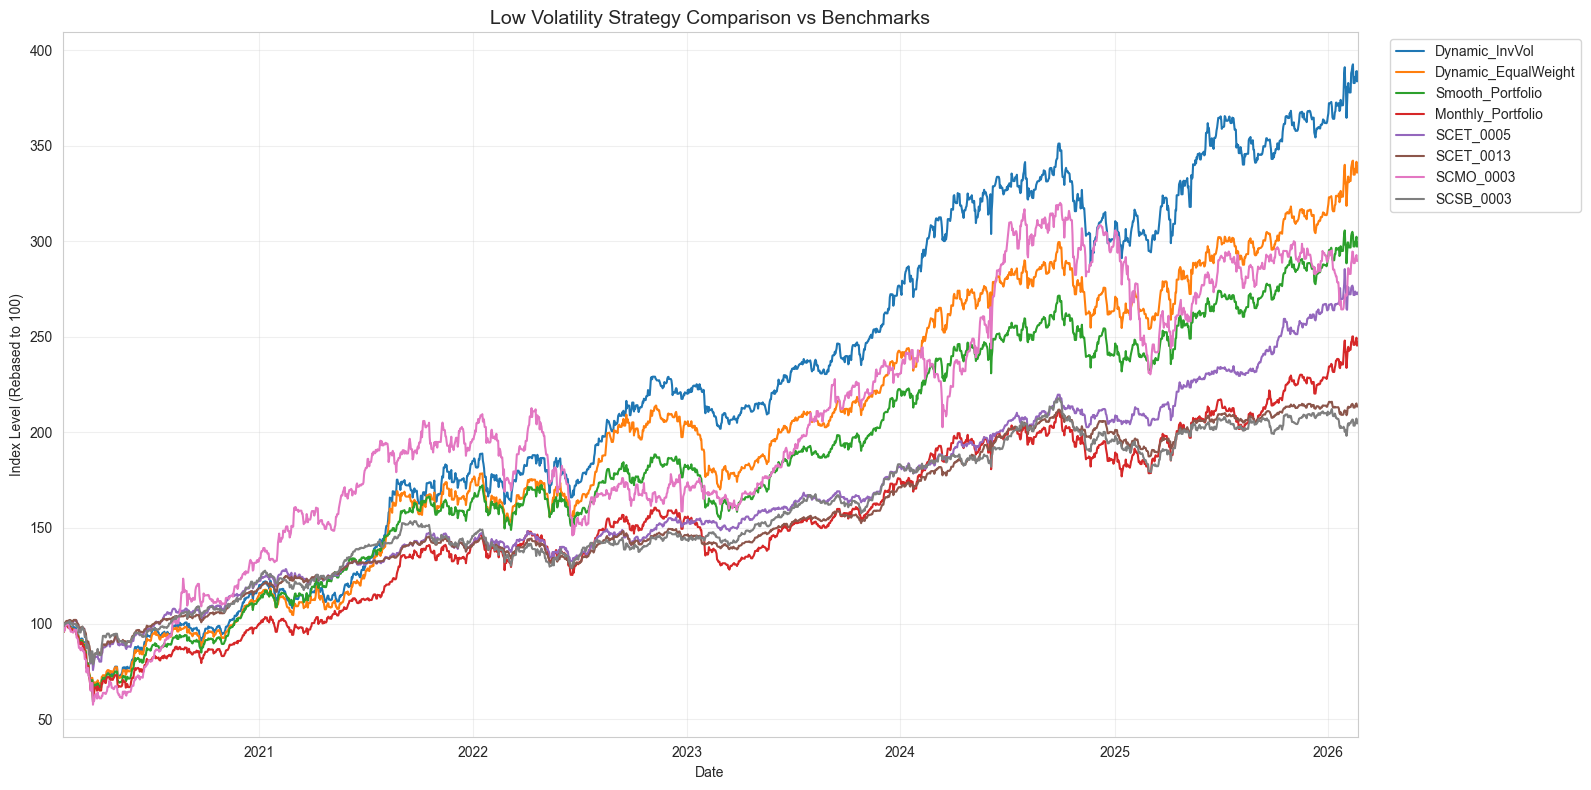

In [18]:
# ── Plot ──────────────────────────────────────────────────────────────────────
plt.figure(figsize=(16, 8))
combined_performance.plot(ax=plt.gca(), linewidth=1.5)
plt.title('Low Volatility Strategy Comparison vs Benchmarks', fontsize=14)
plt.ylabel('Index Level (Rebased to 100)')
plt.xlabel('Date')
plt.grid(True, alpha=0.3)
plt.legend(loc='upper left', bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.show()

In [19]:
# ── Performance Metrics (same as original notebook) ───────────────────────────
def get_metrics(series):
    df_single  = series.to_frame()
    analytics  = qd.IndexAnalytics(indexDf=df_single)

    cagr = float(analytics.getSimpleCGR().iloc[0])
    vol  = float(analytics.getSimpleSTD().iloc[0])

    downside_res = analytics.getDownsideDeviation()
    if isinstance(downside_res, (pd.Series, pd.DataFrame)):
        downside = float(downside_res.iloc[0])
    else:
        downside = float(downside_res)

    daily_ret = series.pct_change().dropna()
    sharpe    = float((daily_ret.mean() * 252) / (daily_ret.std() * np.sqrt(252)))
    sortino   = float((daily_ret.mean() * 252) / (downside * np.sqrt(252)))

    roll_max  = series.cummax()
    md        = float((series / roll_max - 1.0).min())

    return {
        'CAGR (%)':        cagr * 100,
        'Ann. Vol (%)':    vol  * 100,
        'Sharpe':          sharpe,
        'Sortino':         sortino,
        'Max Drawdown (%)': md  * 100,
    }


all_metrics = {}
for col in combined_performance.columns:
    all_metrics[col] = get_metrics(combined_performance[col])

df_metrics = pd.DataFrame(all_metrics)

col_width = 17
sep_line  = '=' * (20 + col_width * len(df_metrics.columns))

print(sep_line)
print(' PORTFOLIO & BENCHMARK PERFORMANCE COMPARISON')
print(sep_line)

header = f" {'Metric':<18} | " + ' | '.join(
    [f"{str(col)[:col_width-2]:>{col_width-2}}" for col in df_metrics.columns]
)
print(header)
print('-' * len(header))

for metric in df_metrics.index:
    row_str = f" {metric:<18} | " + ' | '.join(
        [f"{df_metrics.loc[metric, col]:>{col_width-2}.2f}" for col in df_metrics.columns]
    )
    print(row_str)

print(sep_line)

 PORTFOLIO & BENCHMARK PERFORMANCE COMPARISON
 Metric             |  Dynamic_InvVol | Dynamic_EqualWe | Smooth_Portfoli | Monthly_Portfol |       SCET_0005 |       SCET_0013 |       SCMO_0003 |       SCSB_0003
-------------------------------------------------------------------------------------------------------------------------------------------------------------------
 CAGR (%)           |           16.58 |           14.80 |           13.20 |           10.78 |           12.03 |            8.97 |           12.77 |            8.51
 Ann. Vol (%)       |           17.41 |           16.96 |           15.95 |           16.14 |           10.17 |            7.92 |           20.75 |           11.20
 Sharpe             |            0.97 |            0.90 |            0.86 |            0.72 |            1.17 |            1.13 |            0.69 |            0.79
 Sortino            |            1.33 |            1.25 |            1.16 |            0.96 |            1.65 |            1.54 |     

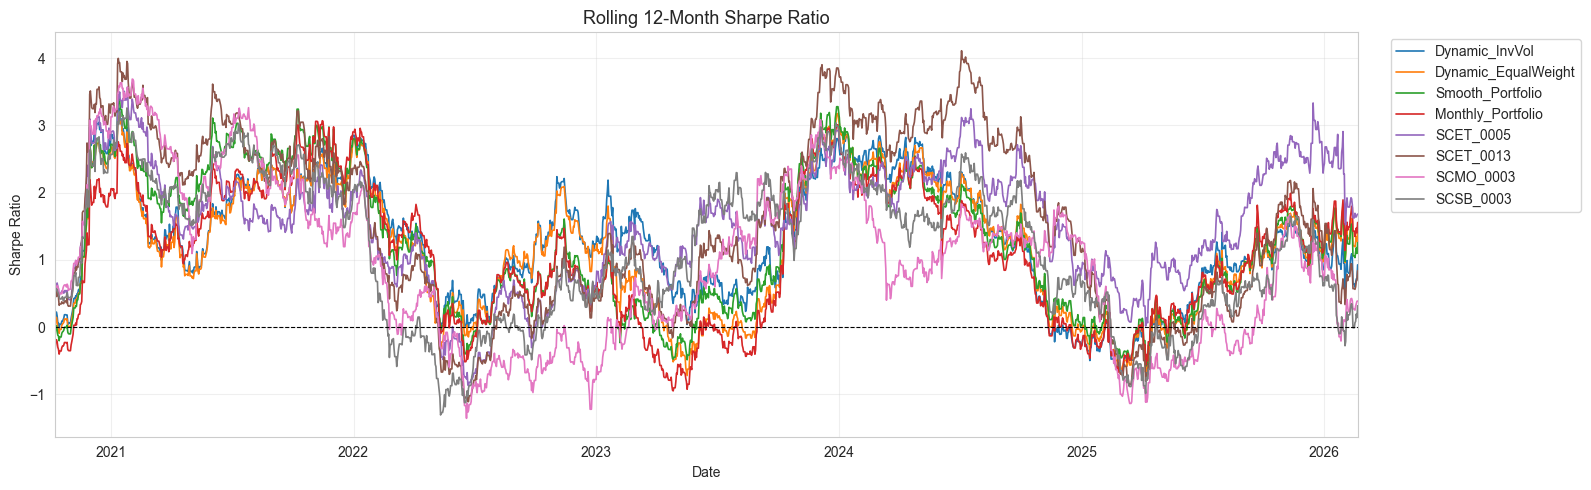

In [20]:
# ── Rolling 12-month Sharpe comparison ───────────────────────────────────────
daily_returns = combined_performance.pct_change().dropna()

rolling_sharpe = (
    daily_returns.rolling(252)
    .apply(lambda x: (x.mean() * 252) / (x.std() * np.sqrt(252)), raw=True)
    .dropna()
)

plt.figure(figsize=(16, 5))
for col in rolling_sharpe.columns:
    rolling_sharpe[col].plot(ax=plt.gca(), linewidth=1.2, label=col)

plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.title('Rolling 12-Month Sharpe Ratio', fontsize=13)
plt.ylabel('Sharpe Ratio')
plt.xlabel('Date')
plt.grid(True, alpha=0.3)
plt.legend(loc='upper left', bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.show()

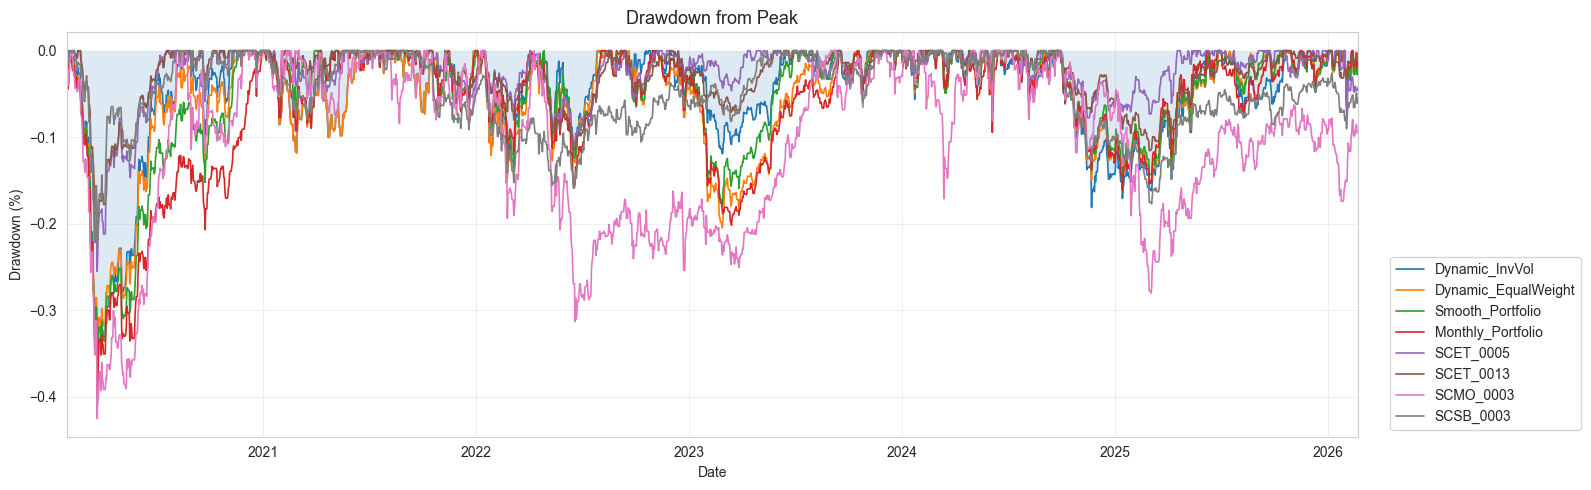

In [21]:
# ── Drawdown chart ─────────────────────────────────────────────────────────────
drawdowns = combined_performance.div(combined_performance.cummax()) - 1.0

plt.figure(figsize=(16, 5))
for col in drawdowns.columns:
    drawdowns[col].plot(ax=plt.gca(), linewidth=1.2, label=col)

# Shade the InvVol dynamic drawdown
if 'Dynamic_InvVol' in drawdowns.columns:
    plt.fill_between(drawdowns.index, drawdowns['Dynamic_InvVol'], 0,
                     alpha=0.15, label='_nolegend_')

plt.title('Drawdown from Peak', fontsize=13)
plt.ylabel('Drawdown (%)')
plt.xlabel('Date')
plt.grid(True, alpha=0.3)
plt.legend(loc='lower left', bbox_to_anchor=(1.02, 0))
plt.tight_layout()
plt.show()

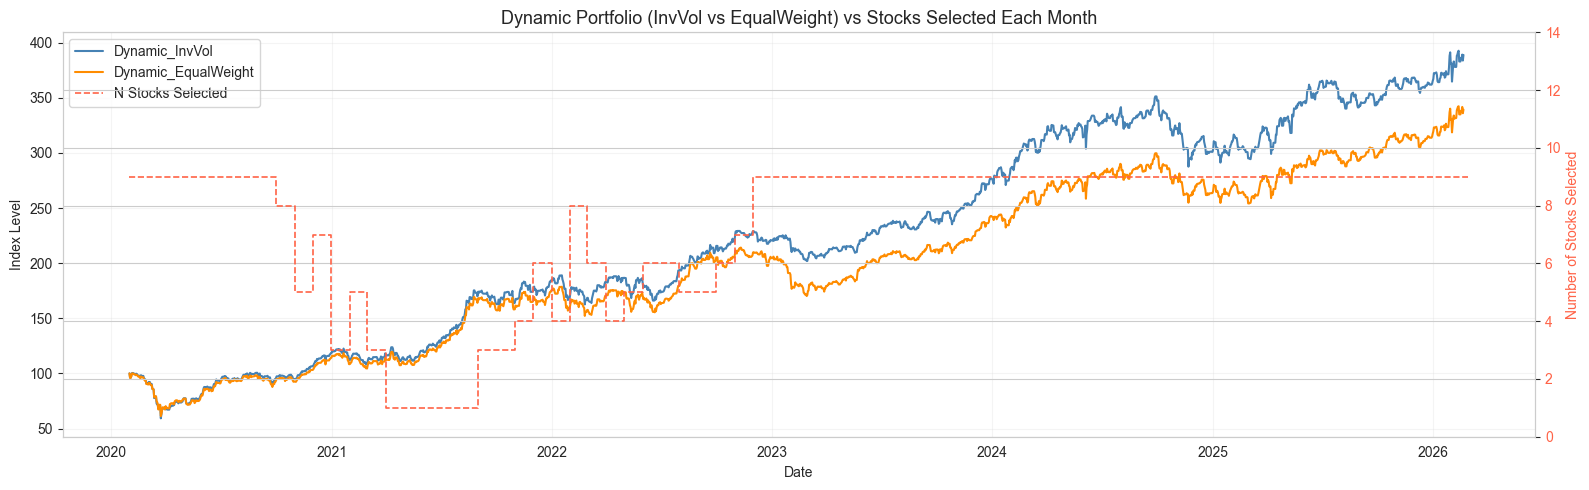

In [22]:
# ── Overlay: Dynamic portfolio size vs index level ────────────────────────────
monthly_sizes = selected_df.groupby('RebalDate')['N_Selected'].first()

fig, ax1 = plt.subplots(figsize=(16, 5))

# Plot both dynamic variants on left axis
colors = {'Dynamic_InvVol': 'steelblue', 'Dynamic_EqualWeight': 'darkorange'}
for col, color in colors.items():
    if col in combined_performance.columns:
        ax1.plot(combined_performance.index, combined_performance[col],
                 color=color, linewidth=1.5, label=col)

ax1.set_ylabel('Index Level')
ax1.set_xlabel('Date')
ax1.grid(True, alpha=0.2)

# N stocks selected on right axis
ax2 = ax1.twinx()
ax2.step(monthly_sizes.index, monthly_sizes.values,
         color='tomato', linewidth=1.2, linestyle='--', where='post',
         label='N Stocks Selected')
ax2.set_ylabel('Number of Stocks Selected', color='tomato')
ax2.tick_params(axis='y', labelcolor='tomato')
ax2.set_ylim(0, MAX_STOCKS + 4)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.title('Dynamic Portfolio (InvVol vs EqualWeight) vs Stocks Selected Each Month',
          fontsize=13)
plt.tight_layout()
plt.show()